## Amoco model
- This is a trust fault system, the data is is come from: https://web.archive.org/web/20220125191916/https://www.seismicatlas.org/entity?id=4cc4ef98-c4e7-4554-8ade-d826de2c66e9
- The fault area are defined as ellipsoids, which is to mimic the finite fault geometry.

In [1]:
import geoinr_faults as grf

Define the model conditions

In [2]:
geomodel = grf.create_geomodel(
    project_name='Amoco',
    extent=[0, 2, 0, 1, 0, 1],
    resolution=[200, 100, 150],
    path_to_surface_points='input_data/Amoco/Amoco_interface.csv',
    path_to_orientations='input_data/Amoco/Amoco_orientation.csv',
)

In [3]:
geomodel

GeoModel('Amoco', extent=[0, 2, 0, 1, 0, 1], resolution=[200, 100, 150], stratis=0, horizons=[], faults=0)

Add stratigraphy column

In [4]:
geomodel = grf.add_stratis(geomodel, strati_configs=[
    grf.StratiConfig(name="strati_A", formations=['Base Cretaceous', 
                                                  'Base Imperial Fm', 
                                                  'Top Hume Fm', 
                                                  'Top Proterozoic']),
])

In [5]:
geomodel

GeoModel('Amoco', extent=[0, 2, 0, 1, 0, 1], resolution=[200, 100, 150], stratis=1, horizons=[4], faults=0)

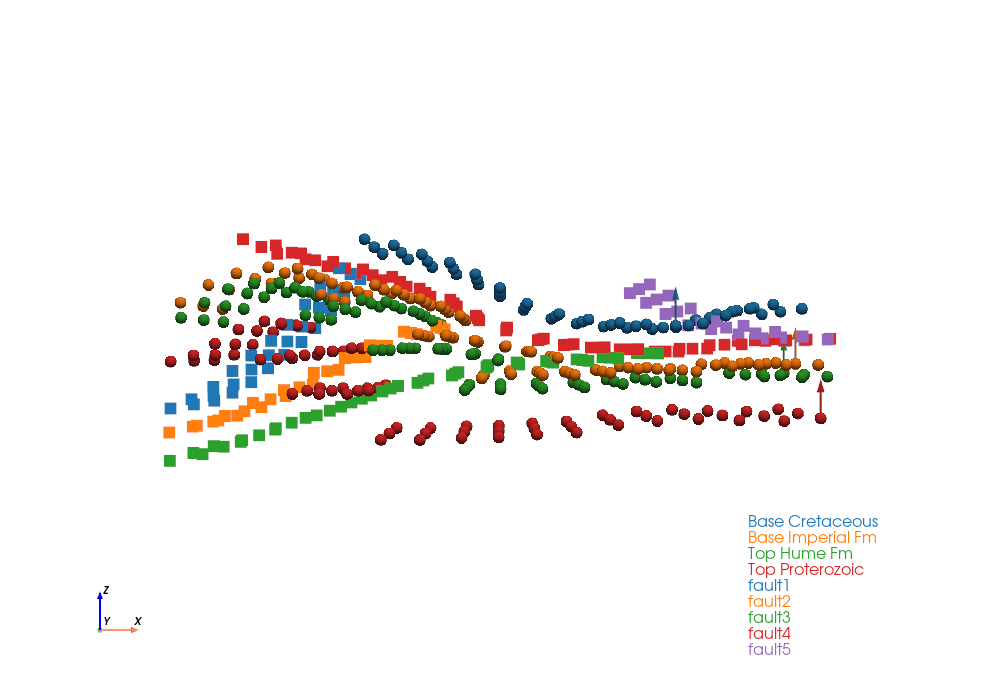

In [6]:
grf.plot_input_data(geomodel, notebook=True, legend_size=(0.22, 0.22))

Add faults, here the fault trunction rules are used, if `truncation` is true, need to define the truncting fault

In [7]:
geomodel = grf.add_faults(geomodel, fault_configs=[
    grf.FaultConfig(name='fault4', lx=10, ly=10, lz=10,
                   dmax=1, lam=0.5, Normal_fault=False),
    grf.FaultConfig(name='fault1', lx=10, ly=10, lz=10,
                   dmax=1, lam=0.5, Normal_fault=False,
                   truncation=True, trunc_fault_name='fault4',
                   hanging_trunc=True), 
    grf.FaultConfig(name='fault2', lx=10, ly=10, lz=10,
                   dmax=1, lam=0.5, Normal_fault=False,
                   truncation=True, trunc_fault_name='fault4',
                   hanging_trunc=True), 
    grf.FaultConfig(name='fault3', lx=10, ly=10, lz=10,
                   dmax=1, lam=0.5, Normal_fault=False,
                   truncation=True, trunc_fault_name='fault4',
                   hanging_trunc=True), 
    grf.FaultConfig(name='fault5', lx=10, ly=0.3, lz=0.3,
                   dmax=1, lam=0.5, Normal_fault=False,
                   truncation=True, trunc_fault_name='fault4',
                   hanging_trunc=False),
])

In [8]:
geomodel

GeoModel('Amoco', extent=[0, 2, 0, 1, 0, 1], resolution=[200, 100, 150], stratis=1, horizons=[4], faults=5)

Visualization of fault feature fields

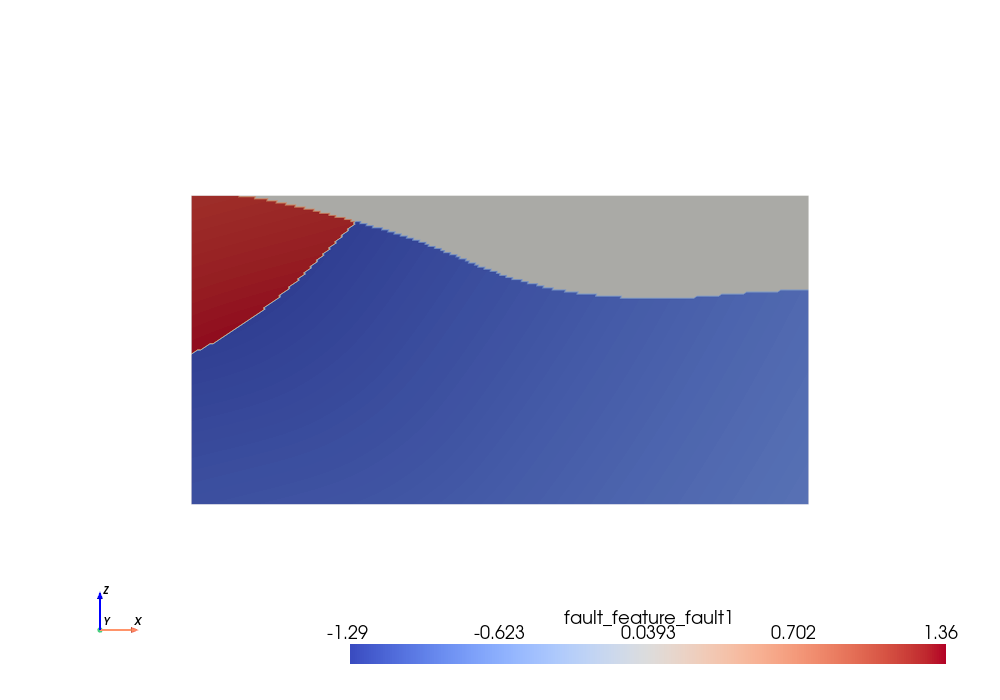

In [9]:
grf.plot_fault_features(geomodel, fault_name='fault1', cmap='coolwarm', notebook=True)

Visualizing fault surfaces

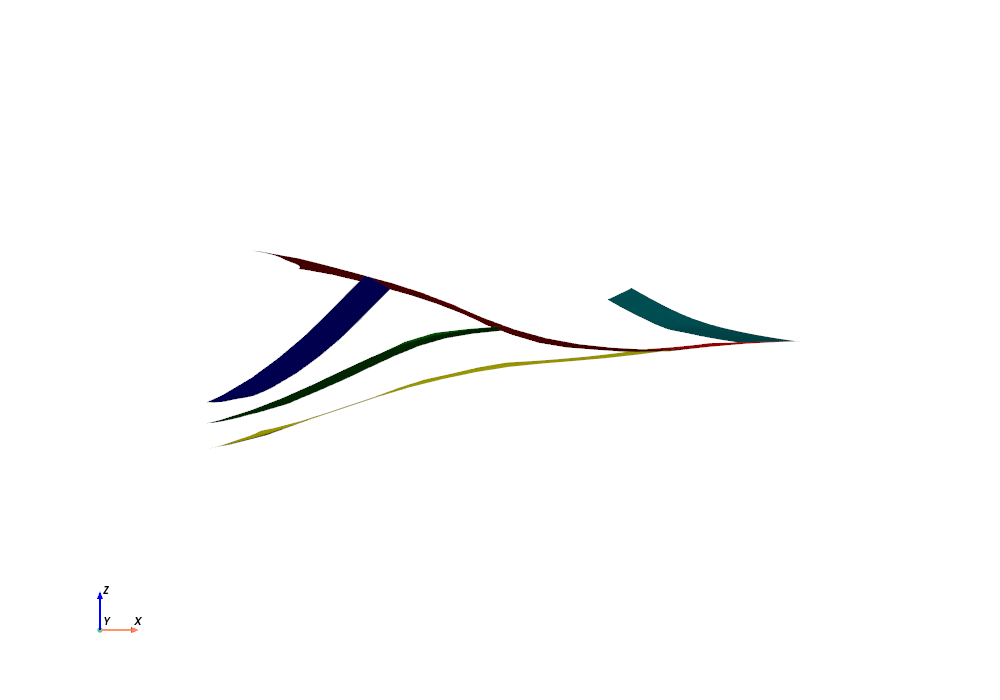

In [10]:
grf.plot_fault_meshes(geomodel, notebook=True)

Compute model

In [11]:
results = grf.compute_model(
    geomodel,
    nn_model='mlp',          # 'mlp' | 'siren' | 'resnet'  or custom class
    hidden_dim=256,
    n_layers=3,
    activation='softplus',   # 'softplus' | 'relu' | 'tanh' | 'sine' | ...
    softplus_beta=30,
    epochs=2000,
    lr=1e-3,
    seed=202507,
)

Epoch [500/2000]  Loss: 0.0240  Var: 0.0001  On: 0.0239  Above: 0.0000  Below: 0.0000  Orie: 0.0000  Best: 0.0240
Epoch [1000/2000]  Loss: 0.0192  Var: 0.0001  On: 0.0192  Above: 0.0000  Below: 0.0000  Orie: 0.0000  Best: 0.0161
Epoch [1500/2000]  Loss: 0.0123  Var: 0.0000  On: 0.0123  Above: 0.0000  Below: 0.0000  Orie: 0.0000  Best: 0.0121
Epoch [2000/2000]  Loss: 0.0103  Var: 0.0000  On: 0.0103  Above: 0.0000  Below: 0.0000  Orie: 0.0000  Best: 0.0103

Training finished in 10.9 s  |  Best loss: 0.0103
Inference completed in 2.6967 s


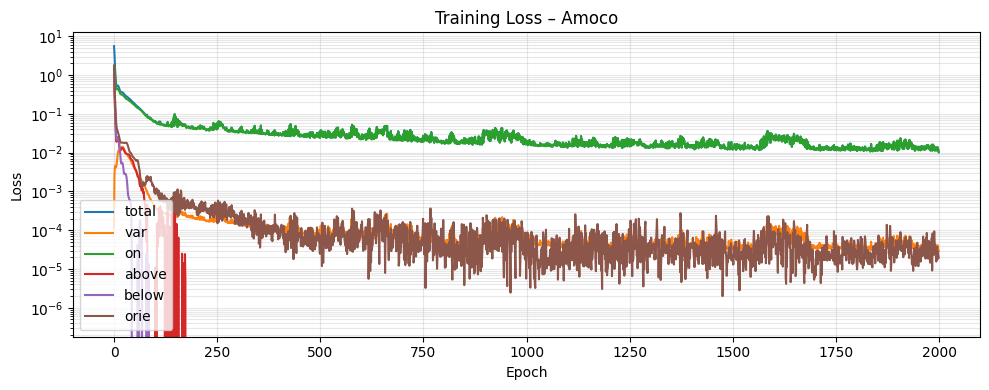

In [12]:
grf.plot_loss(results)

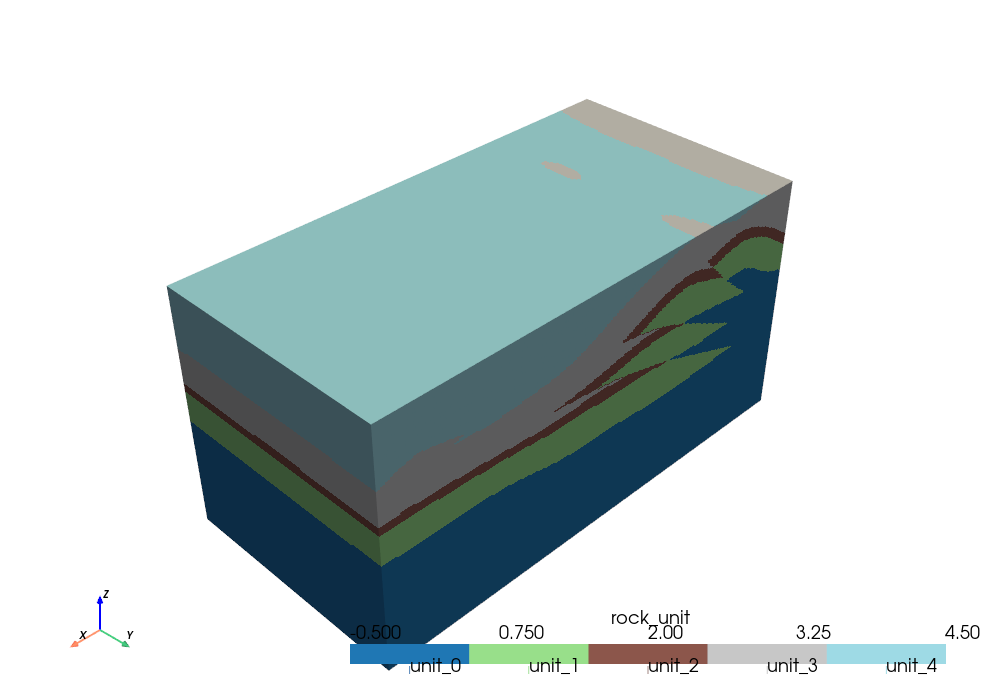

In [13]:
grf.plot_model(results, notebook=True, show_scalar_field=False, show_rock_unit=True)

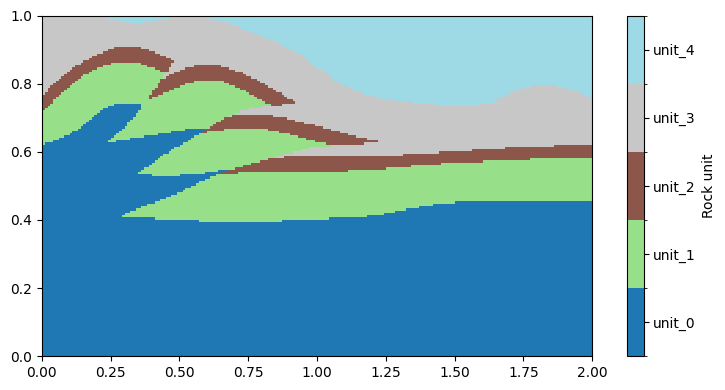

In [14]:
grf.plot_section_rock_unit(results, axis='y',figsize=(7.5, 4))